In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

# Adjust the path according to the actual location of your file in Google Drive
data = pd.read_csv('/content/drive/My Drive/BankChurners.csv')


In [ ]:
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [ ]:
data.sample(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
8681,787226508,Existing Customer,47,M,2,College,Single,$60K - $80K,Blue,41,...,20811.0,1302,19509.0,0.793,7192,82,0.708,0.063,0.000294,0.999710
1085,789920883,Existing Customer,45,F,3,Graduate,Single,Unknown,Blue,36,...,11189.0,2517,8672.0,2.041,2959,58,1.231,0.225,0.000535,0.999460
5488,788552658,Existing Customer,46,F,4,Uneducated,Married,Less than $40K,Blue,30,...,2479.0,1759,720.0,0.810,4562,86,0.720,0.710,0.000117,0.999880
7484,717666783,Attrited Customer,56,F,3,College,Single,Less than $40K,Blue,46,...,2272.0,1350,922.0,0.762,2354,49,0.960,0.594,0.996740,0.003265
4045,716022258,Attrited Customer,51,F,3,College,Single,Less than $40K,Blue,36,...,8960.0,2222,6738.0,0.382,1853,40,0.333,0.248,0.996740,0.003265


In [ ]:
data.isnull().sum().sum()

0

No missing values

In [ ]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])


Number of rows: 10127
Number of columns: 23


In [ ]:
# Selecting all rows and columns from 0 to 21
data = data.iloc[:, 0:21]


In [ ]:
data.shape

(10127, 21)

In [ ]:
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


Class Proportion:
 Attrition_Flag
Existing Customer    0.83934
Attrited Customer    0.16066
Name: proportion, dtype: float64


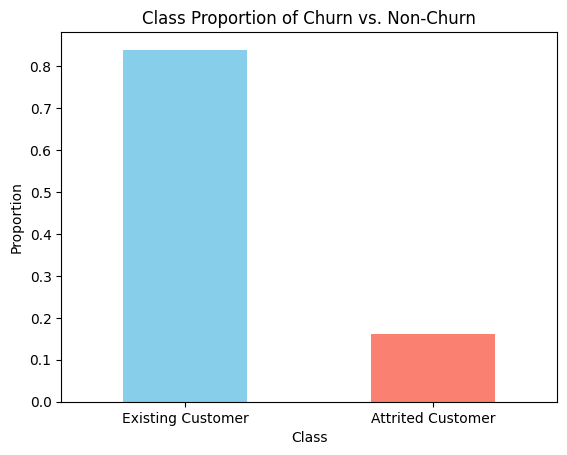

In [ ]:
# Assuming 'Attrition_Flag' is the target column in your dataset
# 1 represents churners and 0 represents non-churners in this example
class_counts = data['Attrition_Flag'].value_counts(normalize=True)  # normalize=True gives proportion
print("Class Proportion:\n", class_counts)

# Visualize class distribution (optional)
import matplotlib.pyplot as plt

class_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Proportion of Churn vs. Non-Churn')
plt.xlabel('Class')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()


# Chi-Square Test

**H0:** The variables are independent, there is no relationship between the two categorical variables.

**HA:** The variables are dependent, there is a relationship between the two categorical variables.

**Significant Level** (α : 0.05)



In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

def chi_square_tests(data, target, columns, alpha=0.05):
    for col in columns:
        print(f"\nChi-square Test between '{target}' and '{col}'")

        # Create a contingency table
        contingency_table = pd.crosstab(data[target], data[col])

        # Perform the Chi-square test
        chi_square_stat, p_value, dof, expected = chi2_contingency(contingency_table)

        # Display results
        print("Contingency Table:\n", contingency_table)
        print("Chi-square Statistic:", chi_square_stat)
        print("Degrees of Freedom:", dof)
        print("P-value:", p_value)

        # Interpretation
        if p_value < alpha:
            print("Reject the null hypothesis. There is a significant relationship between the variables.")
        else:
            print("Fail to reject the null hypothesis. There is no significant relationship between the variables.")
        print("-" * 50)

# Usage
# Replace 'data' with your actual DataFrame
columns_to_test = ['Gender','Education_Level', 'Card_Category', 'Income_Category', 'Marital_Status']
chi_square_tests(data, 'Attrition_Flag', columns_to_test)



Chi-square Test between 'Attrition_Flag' and 'Gender'
Contingency Table:
 Gender                F     M
Attrition_Flag               
Attrited Customer   930   697
Existing Customer  4428  4072
Chi-square Statistic: 13.865613700637342
Degrees of Freedom: 1
P-value: 0.00019635846717310269
Reject the null hypothesis. There is a significant relationship between the variables.
--------------------------------------------------

Chi-square Test between 'Attrition_Flag' and 'Education_Level'
Contingency Table:
 Education_Level    College  Doctorate  Graduate  High School  Post-Graduate  \
Attrition_Flag                                                                
Attrited Customer      154         95       487          306             92   
Existing Customer      859        356      2641         1707            424   

Education_Level    Uneducated  Unknown  
Attrition_Flag                          
Attrited Customer         237      256  
Existing Customer        1250     1263  
Chi-squ

 The target variable Attrition_Flag is related to the categorical features Income_Category and Gender. This indicates that these features have a significant association with churn and may influence customer attrition.








# Mann-Whitney U Test

**H₀ :** The distributions of the two groups are identical.

**H₁ :** The distributions of the two groups are different.

**Significant Level** (α : 0.05)

# **Credit limit**

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Credit_Limit']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Credit_Limit']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in Credit_Limit between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in Credit_Limit between the two groups.")



Mann-Whitney U Test Statistic: 6361348.0
p-value: 3.0078405911217964e-07
Reject the null hypothesis - there is a significant difference in Credit_Limit between the two groups.


# **customer age**

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Customer_Age']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Customer_Age']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in customer age  between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in customer age  between the two groups.")



Mann-Whitney U Test Statistic: 7104960.5
p-value: 0.07809994878128952
Fail to reject the null hypothesis - there is no significant difference in customer age  between the two groups.


# **Dependent Count**

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Dependent_count']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Dependent_count']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in dependent count between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in dependent count between the two groups.")



Mann-Whitney U Test Statistic: 7137310.0
p-value: 0.03472885782137149
Reject the null hypothesis - there is a significant difference in dependent count between the two groups.


# **Months_on_book**

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Months_on_book']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Months_on_book']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in Months_on_book between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in Months_on_book between the two groups.")



Mann-Whitney U Test Statistic: 7079837.5
p-value: 0.12366716741255608
Fail to reject the null hypothesis - there is no significant difference in Months_on_book between the two groups.


# **Total_Relationship_Count**

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Total_Relationship_Count']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Total_Relationship_Count']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in Total_Relationship_Count between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in Total_Relationship_Count between the two groups.")



Mann-Whitney U Test Statistic: 5315342.0
p-value: 2.905716669854199e-51
Reject the null hypothesis - there is a significant difference in Total_Relationship_Count between the two groups.


# **Months_Inactive_12_mon**

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Months_Inactive_12_mon']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Months_Inactive_12_mon']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in Months_Inactive_12_mon between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in Months_Inactive_12_mon between the two groups.")



Mann-Whitney U Test Statistic: 8687418.0
p-value: 5.4231160241902516e-67
Reject the null hypothesis - there is a significant difference in Months_Inactive_12_mon between the two groups.


# **Contacts_Count_12_mon**

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Contacts_Count_12_mon']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Contacts_Count_12_mon']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in Contacts_Count_12_mon between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in Contacts_Count_12_mon between the two groups.")



Mann-Whitney U Test Statistic: 8890849.5
p-value: 1.1108884976394835e-80
Reject the null hypothesis - there is a significant difference in Contacts_Count_12_mon between the two groups.


# Total_Revolving_Bal

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Total_Revolving_Bal']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Total_Revolving_Bal']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in Total_Revolving_Bal between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in Total_Revolving_Bal between the two groups.")



Mann-Whitney U Test Statistic: 4318784.0
p-value: 1.9156786730316762e-129
Reject the null hypothesis - there is a significant difference in Total_Revolving_Bal between the two groups.


# Avg_Open_To_Buy

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Avg_Open_To_Buy']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Avg_Open_To_Buy']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in Avg_Open_To_Buy between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in Avg_Open_To_Buy between the two groups.")



Mann-Whitney U Test Statistic: 7213717.0
p-value: 0.005652366314054008
Reject the null hypothesis - there is a significant difference in Avg_Open_To_Buy between the two groups.


# **Total_Amt_Chng_Q4_Q1**

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Total_Amt_Chng_Q4_Q1']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Total_Amt_Chng_Q4_Q1']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in Total_Amt_Chng_Q4_Q1 between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in Total_Amt_Chng_Q4_Q1 between the two groups.")



Mann-Whitney U Test Statistic: 5806261.5
p-value: 1.0644743098554122e-24
Reject the null hypothesis - there is a significant difference in Total_Amt_Chng_Q4_Q1 between the two groups.


# **Total_Trans_Amt**

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Total_Trans_Amt']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Total_Trans_Amt']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in Total_Trans_Amt between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in TTotal_Trans_Amt between the two groups.")



Mann-Whitney U Test Statistic: 4481880.0
p-value: 2.719009390771486e-112
Reject the null hypothesis - there is a significant difference in Total_Trans_Amt between the two groups.


# **Total_Trans_Ct**

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Total_Trans_Ct']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Total_Trans_Ct']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in Total_Trans_Ct between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in Total_Trans_Ct between the two groups.")



Mann-Whitney U Test Statistic: 2826174.0
p-value: 0.0
Reject the null hypothesis - there is a significant difference in Total_Trans_Ct between the two groups.


# **Total_Ct_Chng_Q4_Q1**

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Total_Ct_Chng_Q4_Q1']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Total_Ct_Chng_Q4_Q1']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in Total_Ct_Chng_Q4_Q1 between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in Total_Ct_Chng_Q4_Q1between the two groups.")



Mann-Whitney U Test Statistic: 3522217.0
p-value: 1.908240659213709e-216
Reject the null hypothesis - there is a significant difference in Total_Ct_Chng_Q4_Q1 between the two groups.


# **Avg_Utilization_Ratio**

In [ ]:
import pandas as pd
from scipy.stats import mannwhitneyu

attrition_yes = data[data['Attrition_Flag'] == 'Attrited Customer']['Avg_Utilization_Ratio']
attrition_no = data[data['Attrition_Flag'] == 'Existing Customer']['Avg_Utilization_Ratio']


# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(attrition_yes, attrition_no, alternative='two-sided')

print("Mann-Whitney U Test Statistic:", stat)
print("p-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis - there is a significant difference in Avg_Utilization_Ratio between the two groups.")
else:
    print("Fail to reject the null hypothesis - there is no significant difference in Avg_Utilization_Ratio between the two groups.")



Mann-Whitney U Test Statistic: 4320406.5
p-value: 2.869097017266704e-129
Reject the null hypothesis - there is a significant difference in Avg_Utilization_Ratio between the two groups.


**Significant Differences:**

Most financial and behavioral metrics, like Credit_Limit, Dependent_count, Total_Relationship_Count, Months_Inactive_12_mon, and various transaction-related features, show significant differences between the two groups (Attrited vs. Existing Customers).
These significant differences suggest that these features may have a meaningful impact on customer attrition and could be key predictors in a model.

**Non-Significant Differences:**

Customer_Age and Months_on_book show no significant difference between the two groups. This implies that age and tenure with the bank might not directly relate to attrition behavior in this dataset.

# Spearman's Rank correlation


**H₀ :** There is no monotonic relationship between the two variables.

**H₁ :** There is a monotonic relationship between the two variables (either positive or negative).

**Significant Level**(α : 0.05)

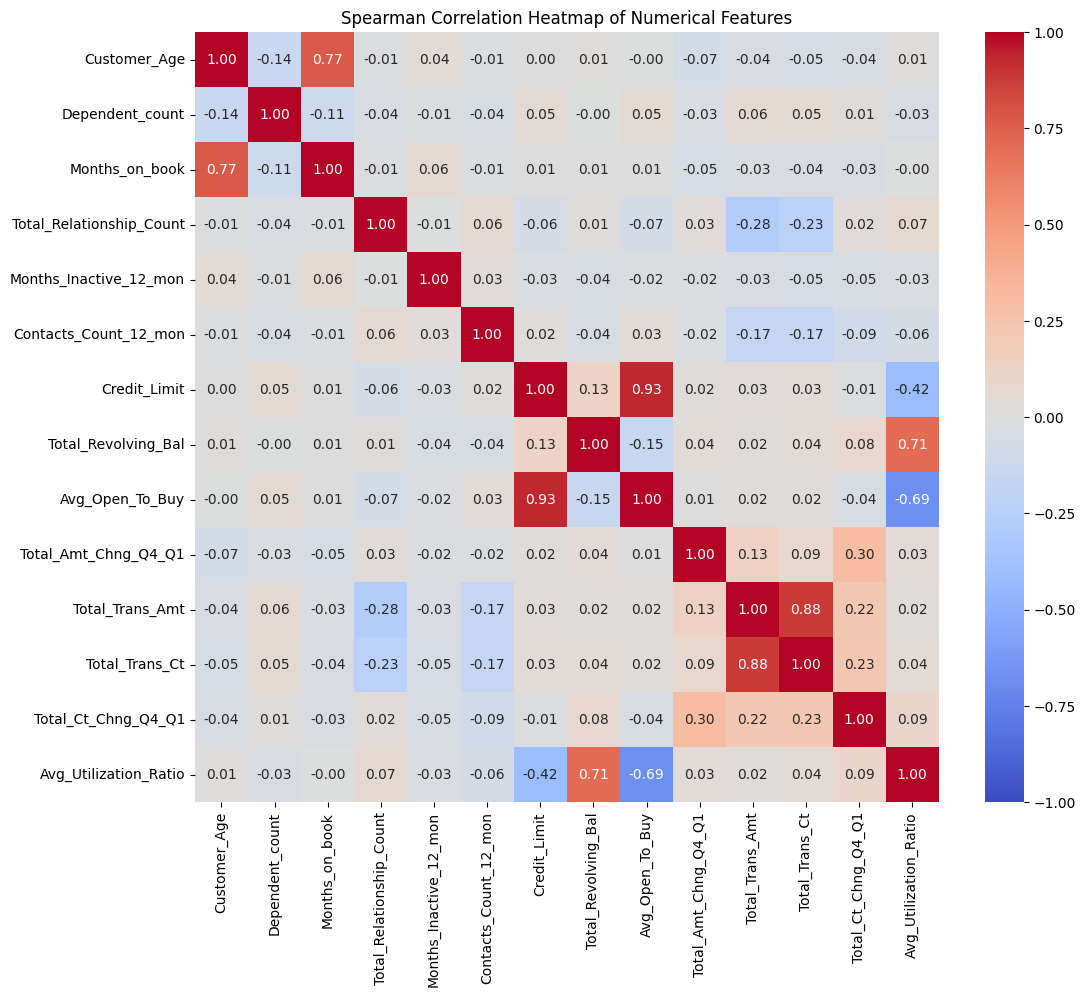

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting only the numerical columns from the data
numerical_columns = [
    'Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count',
    'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
    'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]

# Compute Spearman's correlation matrix
spearman_corr = data[numerical_columns].corr(method='spearman')

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Spearman Correlation Heatmap of Numerical Features")
plt.show()


**Credit and Utilization:**

**Credit_Limit and Avg_Open_To_Buy (0.93):**Strong positive correlation indicates that customers with higher credit limits generally have more available credit.

**Avg_Utilization_Ratio and Total_Revolving_Bal (0.71):**  Higher revolving balances are associated with higher utilization ratios, suggesting more intensive credit usage.

**Credit_Limit and Avg_Utilization_Ratio (-0.42):** Moderate negative correlation; customers with higher credit limits tend to have lower utilization ratios, potentially indicating lower credit dependency.
Transaction Patterns:

**Total_Trans_Amt and Total_Trans_Ct (0.88):**High correlation between transaction amount and count, showing that customers who transact more frequently also spend more. This suggests high engagement among active users.

**Total_Amt_Chng_Q4_Q1 and Total_Ct_Chng_Q4_Q1 (0.30):**
Moderate positive correlation indicates a relationship between changes in transaction amount and transaction count from Q4 to Q1, reflecting spending pattern shifts over time.
Customer Profile:

**Customer_Age and Months_on_book (0.77):**Older customers have been with the bank longer, suggesting age is positively associated with account longevity.
Low to Minimal Correlations:


Dependent_count, Months_Inactive_12_mon, and Contacts_Count_12_mon show weak correlations with other variables, indicating minimal association with other customer behaviors or credit metrics.



## **Summary:**
***Credit Behavior:*** Strong interconnections among Credit_Limit, Avg_Open_To_Buy, and Avg_Utilization_Ratio indicate that credit usage and availability are key behavioral markers.

***Transaction Engagement: ***High correlations between transaction amount and count reveal consistent spending patterns among frequent users.

***Customer Longevity:*** Older age correlates with longer tenure, possibly reflecting customer loyalty or stability.

# Kolmogorov-Smirnov Test

**H₀ :** The two samples are drawn from the same distribution.

**H₁ :**The two samples are drawn from different distributions.

**Significant Level**(α : 0.05)

In [ ]:
import pandas as pd
from scipy.stats import ks_2samp


# Define continuous columns to test
continuous_columns = [
    'Customer_Age', 'Credit_Limit', 'Total_Relationship_Count', 'Months_on_book',
    'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]

# Separate data into churners and non-churners
churners = data[data['Attrition_Flag'] == 'Attrited Customer']
non_churners = data[data['Attrition_Flag'] == 'Existing Customer']

# Initialize results dictionary to store the output
results = {}

for col in continuous_columns:

    # Perform KS test
    stat, p_value = ks_2samp(churned_data, non_churned_data)

    # Store results
    results[col] = {'statistic': stat, 'p_value': p_value}

# Convert results to DataFrame for easier viewing
ks_results = pd.DataFrame(results).T
ks_results['significant'] = ks_results['p_value'] < 0.05

# Display results
print(ks_results)


                          statistic        p_value  significant
Customer_Age               0.035957   5.693640e-02        False
Credit_Limit               0.116053   1.769992e-16         True
Total_Relationship_Count   0.192427   1.012547e-44         True
Months_on_book             0.032094   1.170811e-01        False
Total_Revolving_Bal        0.443710  8.093862e-244         True
Avg_Open_To_Buy            0.132513   2.296391e-21         True
Total_Amt_Chng_Q4_Q1       0.167343   7.132385e-34         True
Total_Trans_Amt            0.484606  2.831369e-293         True
Total_Trans_Ct             0.550507  5.518713e-321         True
Total_Ct_Chng_Q4_Q1        0.411329  2.581716e-208         True
Avg_Utilization_Ratio      0.383815  1.398880e-180         True


**Customer_Age:** No significant difference between churners and non-churners.

**Credit_Limit:** Significant difference. Credit limits vary notably between churners and non-churners, potentially influencing churn behavior.

**Total_Relationship_Count: **Significant difference. A higher relationship count may correlate with retention.

**Months_on_book:** No significant difference, indicating tenure alone doesn’t distinguish churners from non-churners.

**Total_Revolving_Bal:** Significant difference. Differences in revolving balance patterns likely affect churn.

**Avg_Open_To_Buy:** Significant difference. Available credit differs, potentially impacting churn risk.

**Total_Amt_Chng_Q4_Q1:** Significant difference. Changes in transaction amounts vary between groups.

**Total_Trans_Amt:** Significant difference. Total transaction amounts differ, possibly reflecting engagement levels.

**Total_Trans_Ct:** Significant difference. Transaction frequency is notably different, potentially indicating retention.

**Total_Ct_Chng_Q4_Q1:** Significant difference. Quarterly changes in transaction count may relate to churn behavior.

**Avg_Utilization_Ratio: **Significant difference. Credit utilization patterns vary and may affect churn risk.

# Mood's Median Test

**H₀ :** The medians of all groups are the same.

**H₁ :** At least one group has a different median.


**Significant Level**(α : 0.05)

In [ ]:
import pandas as pd
from scipy.stats import median_test

# Assuming 'data' is your DataFrame loaded with the Bank Churners data
# data = pd.read_csv('path_to_your_data.csv')

# Define continuous columns for median test
continuous_columns = [
    'Customer_Age', 'Credit_Limit', 'Total_Relationship_Count', 'Months_on_book',
    'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]

# Separate data into churners and non-churners
churners = data[data['Attrition_Flag'] == 'Attrited Customer']
non_churners = data[data['Attrition_Flag'] == 'Existing Customer']

# Initialize results dictionary to store the output
results = {}

for col in continuous_columns:
    # Perform Mood’s Median Test
    stat, p_value, med, tbl = median_test(churners[col].dropna(), non_churners[col].dropna())

    # Store results
    results[col] = {'statistic': stat, 'p_value': p_value, 'overall_median': med}

# Convert results to DataFrame for easier viewing
median_test_results = pd.DataFrame(results).T
median_test_results['significant'] = median_test_results['p_value'] < 0.05

# Display results
print(median_test_results)


                            statistic        p_value  overall_median  \
Customer_Age                 0.852522   3.558397e-01          46.000   
Credit_Limit                 9.383006   2.190062e-03        4549.000   
Total_Relationship_Count   101.782727   6.195807e-24           4.000   
Months_on_book               0.253234   6.148070e-01          36.000   
Total_Revolving_Bal        473.165258  6.561305e-105        1276.000   
Avg_Open_To_Buy              0.003419   9.533753e-01        3474.000   
Total_Amt_Chng_Q4_Q1        45.708396   1.372333e-11           0.736   
Total_Trans_Amt            734.971500  7.433314e-162        3899.000   
Total_Trans_Ct            1270.070122  3.609626e-278          67.000   
Total_Ct_Chng_Q4_Q1        525.768063  2.353079e-116           0.702   
Avg_Utilization_Ratio      358.724643   5.336918e-80           0.176   

                          significant  
Customer_Age                    False  
Credit_Limit                     True  
Total_Relations

**Customer_Age:** No significant difference in median age between churners and non-churners (median = 46).

**Credit_Limit:** Significant difference. Churners and non-churners differ in credit limits (median = 4549).

**Total_Relationship_Count:** Significant difference. Number of relationships with the bank is higher for one group (median = 4).

**Months_on_book:** No significant difference in tenure (median = 36 months), suggesting tenure doesn’t affect churn likelihood.

**Total_Revolving_Bal:** Significant difference. Different revolving balance levels between groups (median = 1276), possibly indicating varied credit behaviors.

**Avg_Open_To_Buy:** No significant difference in open-to-buy credit (median = 3474), showing similar available credit across groups.

**Total_Amt_Chng_Q4_Q1:** Significant difference in transaction amount changes between quarters (median = 0.736), hinting at varied spending behavior changes.

**Total_Trans_Amt:** Significant difference in total transaction amounts (median = 3899), reflecting different spending levels.

**Total_Trans_Ct:** Significant difference in transaction counts (median = 67), suggesting churners and non-churners have different transaction frequencies.

**Total_Ct_Chng_Q4_Q1:** Significant difference in transaction count change (median = 0.702), indicating different transaction frequency trends.

**Avg_Utilization_Ratio:** Significant difference in utilization ratio (median = 0.176), suggesting distinct credit usage patterns.

# uh can add this in group or uh can find something better like this

Most financial and transactional features show significant median differences between churners and non-churners, indicating these metrics are likely associated with churn behavior. Features like Credit_Limit, Total_Trans_Amt, and Avg_Utilization_Ratio may be particularly useful for identifying churn-prone customers.

In [ ]:
data.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')